**Chapter 3 - Exercise 3.48**

Part 1: Intermediate Configurations
Final Matrix T1:
[[-1.     -0.      0.     -2.    ]
 [ 0.     -1.      0.      4.    ]
 [ 0.      0.      1.      6.2832]
 [ 0.     -0.      0.      1.    ]]

Part 2: Return Axis (S1)
Distance theta1: 3.1416 rad
Parameter h1: -2.0000
Direction Vector s1: [-0. -0.  1.]
Point on axis q1: [-1.  2.  0.]


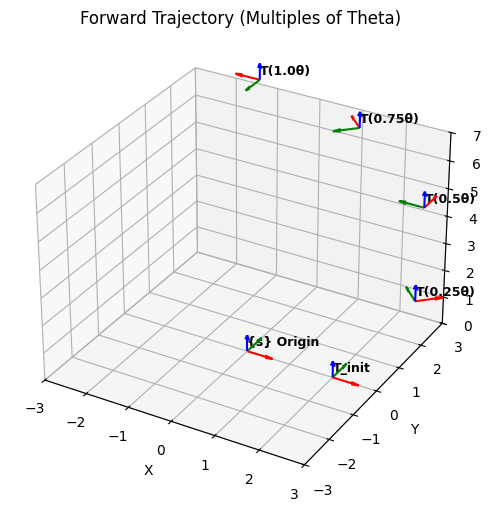

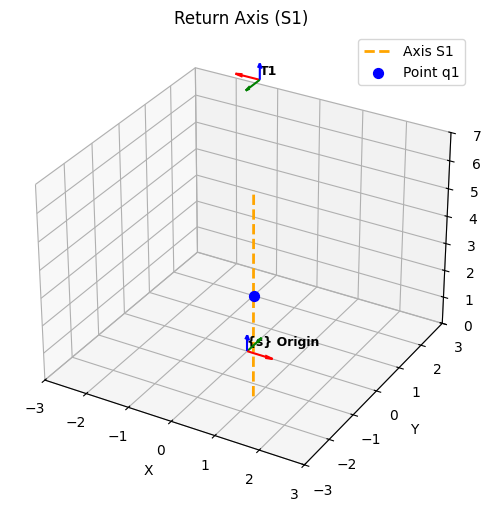

In [41]:
import numpy as np
from scipy.linalg import expm, logm
import matplotlib.pyplot as plt

def skew(v):
    return np.array([[0, -v[2], v[1]],
                     [v[2],  0, -v[0]],
                     [-v[1], v[0],  0]])

def deskew(M):
    return np.array([M[2,1], M[0,2], M[1,0]])

def screw_vector(q, s, h):
    s = s / np.linalg.norm(s)
    w = s
    v = -np.cross(s, q) + h * s
    S = np.zeros((4, 4))
    S[:3, :3] = skew(w)
    S[:3, 3] = v
    return S

def get_T(S, theta):
    return expm(S * theta)

def get_screw_from_T(T):
    R = T[:3, :3]
    p = T[:3, 3]
    trace = np.trace(R)

    if np.isclose(trace, 1.0):
        theta = np.linalg.norm(p)
        if np.isclose(theta, 0):
            return np.zeros(6), 0.0
        return np.concatenate((np.zeros(3), p / theta)), theta

    elif np.isclose(trace, -1.0):
        theta = np.pi
        r11, r22, r33 = R[0,0], R[1,1], R[2,2]

        if not np.isclose(1 + r11, 0):
            w = (1 / np.sqrt(2 * (1 + r11))) * np.array([1 + r11, R[1,0], R[2,0]])
        elif not np.isclose(1 + r22, 0):
            w = (1 / np.sqrt(2 * (1 + r22))) * np.array([R[0,1], 1 + r22, R[2,1]])
        else:
            w = (1 / np.sqrt(2 * (1 + r33))) * np.array([R[0,2], R[1,2], 1 + r33])
        w_skew = skew(w)

    else:
        theta = np.arccos(0.5 * (trace - 1))
        w_skew = (R - R.T) / (2 * np.sin(theta))
        w = deskew(w_skew)


    cot_half_theta = 0.0 if np.isclose(theta, np.pi) else 1.0 / np.tan(theta / 2.0)

    G_inv = np.eye(3) / theta - 0.5 * w_skew + (1.0 / theta - 0.5 * cot_half_theta) * (w_skew @ w_skew)
    v = G_inv @ p
    return np.concatenate((w, v)), theta

def get_qsh_from_S(S_vec):
    w = S_vec[:3]
    v = S_vec[3:]
    s = w
    h = np.dot(w, v)
    q = np.cross(w, v)
    return q, s, h

def plot_frame(ax, T, label):
    p = T[:3, 3]
    x = T[:3, 0] * 0.6
    y = T[:3, 1] * 0.6
    z = T[:3, 2] * 0.6

    ax.quiver(*p, *x, color='r', linewidth=1.5)
    ax.quiver(*p, *y, color='g', linewidth=1.5)
    ax.quiver(*p, *z, color='b', linewidth=1.5)
    ax.text(p[0], p[1], p[2]+0.2, label, fontsize=9, fontweight='bold')

def setup_plot(title):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_xlim([-3, 3])
    ax.set_ylim([-3, 3])
    ax.set_zlim([0, 7])

    plot_frame(ax, np.eye(4), '{s} Origin')
    return ax

def main():
    T_initial = np.array([
        [1, 0, 0, 2],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    q = np.array([0, 2, 0])
    s_hat = np.array([0, 0, 1])
    h = 2
    theta_total = np.pi

    S_mat = screw_vector(q, s_hat, h)

    # Part 1: Forward Trajectory
    fractions = [0, 0.25, 0.5, 0.75, 1.0]
    poses = []

    print("Part 1: Intermediate Configurations")
    ax1 = setup_plot("Forward Trajectory (Multiples of Theta)")

    for f in fractions:
        theta_current = f * theta_total
        T_movement = get_T(S_mat, theta_current)
        T_current = T_movement @ T_initial
        poses.append(T_current)

        label = f"T({f}θ)" if f > 0 else "T_init"
        plot_frame(ax1, T_current, label)

        if f == 1.0:
            print("Final Matrix T1:")
            print(np.round(T_current, 4))

    T1 = poses[-1]

    # Part 2: Return Axis (S1)
    print("\nPart 2: Return Axis (S1)")

    T_return = np.linalg.inv(T1)

    S1_vec, theta1 = get_screw_from_T(T_return)
    q1, s1, h1 = get_qsh_from_S(S1_vec)

    print(f"Distance theta1: {theta1:.4f} rad")
    print(f"Parameter h1: {h1:.4f}")
    print(f"Direction Vector s1: {np.round(s1, 4)}")
    print(f"Point on axis q1: {np.round(q1, 4)}")

    ax2 = setup_plot("Return Axis (S1)")
    plot_frame(ax2, T1, "T1")

    t_line = np.linspace(-4, 4, 100)
    line_x = q1[0] + t_line * s1[0]
    line_y = q1[1] + t_line * s1[1]
    line_z = q1[2] + t_line * s1[2]

    ax2.plot(line_x, line_y, line_z, color='orange', linestyle='--', linewidth=2, label='Axis S1')
    ax2.scatter(*q1, color='blue', s=50, label='Point q1')
    ax2.legend()

    plt.show()

if __name__ == "__main__":
    main()